In [2]:
# =====================================
# Standard Libraries
# =====================================
import os
import random
import zipfile
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# =====================================
# Data Processing
# =====================================
import cv2
import numpy as np
import pandas as pd

# =====================================
# Visualization
# =====================================
import matplotlib.pyplot as plt

# =====================================
# Machine Learning
# =====================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# =====================================
# PyTorch
# =====================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# =====================================
# TorchVision
# =====================================
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.models.video import R3D_18_Weights, r3d_18

# =====================================
# Utilities
# =====================================
from tqdm.auto import tqdm


In [3]:
# =====================================
# Device Configuration
# =====================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")

    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)

        print(f"\nGPU {i}")
        print(f"Name        : {props.name}")
        print(f"Memory      : {props.total_memory / 1024**3:.2f} GB")
        print(f"CUDA Version: {torch.version.cuda}")

else:
    print("No GPU detected. Running on CPU.")

Using device: cuda
Number of GPUs: 2

GPU 0
Name        : Tesla T4
Memory      : 14.56 GB
CUDA Version: 12.8

GPU 1
Name        : Tesla T4
Memory      : 14.56 GB
CUDA Version: 12.8


In [4]:
# =====================================
# Reproducibility
# =====================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [ ]:
# Install gdown (only once per Kaggle session)
!pip install -q gdown
import gdown

In [5]:
# =====================================
# Download Dataset
# =====================================

DATASET_URL = "https://drive.google.com/uc?id=1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-"
DATASET_ZIP = "dataset.zip"

if not os.path.exists(DATASET_ZIP):
    print("Downloading dataset...")
    gdown.download(DATASET_URL, DATASET_ZIP, quiet=False)
else:
    print("Dataset already exists.")

Dataset already exists.


In [6]:
# =====================================
# Extract Dataset
# =====================================

DATASET_DIR = Path("/kaggle/working/Shop DataSet")

if not DATASET_DIR.exists():

    print("Extracting dataset...")

    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
        zip_ref.extractall("/kaggle/working")

    print("Dataset extracted successfully.")

else:
    print("Dataset already extracted.")

Dataset already extracted.


In [8]:

# =====================================
# Check Duplicate Video Content
# Exact MD5 + Strict Visual Match
# =====================================

import hashlib
from itertools import combinations

VIDEO_EXTENSIONS = ("*.mp4", "*.avi", "*.mov", "*.mkv")
DUPLICATE_CLASSES = {
    "non shop lifters": 0,
    "shop lifters": 1
}

# Strict visual matching settings.
# The visual check is intentionally conservative to avoid matching different CCTV
# clips that share the same background/camera angle.
VISUAL_SAMPLE_FRAMES = 24
VISUAL_COMPARE_SIZE = 64
DURATION_TOLERANCE_SECONDS = 1.00
FRAME_COUNT_TOLERANCE_RATIO = 0.02
ASPECT_RATIO_TOLERANCE = 0.02
PIXEL_MAE_THRESHOLD = 10.0
DHASH_DISTANCE_THRESHOLD = 0.04


def calculate_md5(file_path, chunk_size=1024 * 1024):
    """
    Detects exact duplicate files even if filenames are different.
    """
    md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        while chunk := f.read(chunk_size):
            md5.update(chunk)

    return md5.hexdigest()


def collect_dataset_videos(dataset_dir, classes):
    rows = []

    for class_name, label in classes.items():
        class_dir = dataset_dir / class_name

        for pattern in VIDEO_EXTENSIONS:
            for video_path in sorted(class_dir.glob(pattern)):
                rows.append({
                    "video_path": str(video_path),
                    "filename": video_path.name,
                    "class_name": class_name,
                    "label": label
                })

    return pd.DataFrame(rows)


def get_video_metadata(video_path):
    cap = cv2.VideoCapture(str(video_path))

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    cap.release()

    duration = frame_count / fps if fps and fps > 0 else np.nan
    aspect_ratio = width / height if height else np.nan

    return pd.Series({
        "frame_count": frame_count,
        "fps": fps,
        "duration": duration,
        "width": width,
        "height": height,
        "aspect_ratio": aspect_ratio
    })


def dhash(gray_frame):
    resized = cv2.resize(
        gray_frame,
        (VISUAL_COMPARE_SIZE + 1, VISUAL_COMPARE_SIZE),
        interpolation=cv2.INTER_AREA
    )
    return (resized[:, 1:] > resized[:, :-1]).astype(np.uint8).reshape(-1)


def calculate_visual_signature(video_path):
    """
    Builds a strict visual signature from sampled grayscale frames.
    It keeps both small frames and dHash bits so re-encoded copies can still match,
    while different clips from the same CCTV angle usually stay apart.
    """
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        VISUAL_SAMPLE_FRAMES,
        dtype=np.int32
    )

    frames = []
    hashes = []

    for frame_idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()

        if not success or frame is None:
            cap.release()
            return None

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(
            gray,
            (VISUAL_COMPARE_SIZE, VISUAL_COMPARE_SIZE),
            interpolation=cv2.INTER_AREA
        )
        gray = cv2.equalizeHist(gray)

        frames.append(gray.astype(np.float32))
        hashes.append(dhash(gray))

    cap.release()

    return {
        "frames": np.stack(frames),
        "dhash": np.concatenate(hashes)
    }


def is_metadata_candidate(left, right):
    if left["class_name"] == right["class_name"]:
        return False

    if pd.isna(left["duration"]) or pd.isna(right["duration"]):
        return False

    duration_close = abs(left["duration"] - right["duration"]) <= DURATION_TOLERANCE_SECONDS

    max_frames = max(left["frame_count"], right["frame_count"], 1)
    frame_count_close = (
        abs(left["frame_count"] - right["frame_count"]) / max_frames
    ) <= FRAME_COUNT_TOLERANCE_RATIO

    aspect_ratio_close = abs(left["aspect_ratio"] - right["aspect_ratio"]) <= ASPECT_RATIO_TOLERANCE

    return duration_close and frame_count_close and aspect_ratio_close


def compare_visual_signatures(left_sig, right_sig):
    if left_sig is None or right_sig is None:
        return None

    pixel_mae = np.mean(np.abs(left_sig["frames"] - right_sig["frames"]))
    dhash_distance = np.mean(left_sig["dhash"] != right_sig["dhash"])

    return {
        "pixel_mae": float(pixel_mae),
        "dhash_distance": float(dhash_distance),
        "is_match": (
            pixel_mae <= PIXEL_MAE_THRESHOLD and
            dhash_distance <= DHASH_DISTANCE_THRESHOLD
        )
    }


duplicate_df = collect_dataset_videos(DATASET_DIR, DUPLICATE_CLASSES)

if duplicate_df.empty:
    print("No videos found for duplicate checking.")
else:
    tqdm.pandas(desc="MD5")
    duplicate_df["file_md5"] = duplicate_df["video_path"].progress_apply(calculate_md5)

    exact_duplicates = duplicate_df[
        duplicate_df.duplicated("file_md5", keep=False)
    ].sort_values(["file_md5", "class_name", "filename"])

    cross_class_exact_duplicates = exact_duplicates.groupby("file_md5").filter(
        lambda group: group["class_name"].nunique() > 1
    )

    print(f"Total videos checked: {len(duplicate_df)}")
    print(f"Exact duplicate videos: {len(exact_duplicates)}")
    print(f"Cross-class exact duplicates: {len(cross_class_exact_duplicates)}")

    if not cross_class_exact_duplicates.empty:
        display(cross_class_exact_duplicates[[
            "file_md5", "class_name", "filename", "video_path"
        ]])

    tqdm.pandas(desc="Metadata")
    metadata_df = duplicate_df["video_path"].progress_apply(get_video_metadata)
    duplicate_df = pd.concat([duplicate_df, metadata_df], axis=1)

    candidate_pairs = []

    for left_idx, right_idx in combinations(duplicate_df.index, 2):
        left = duplicate_df.loc[left_idx]
        right = duplicate_df.loc[right_idx]

        if is_metadata_candidate(left, right):
            candidate_pairs.append((left_idx, right_idx))

    print(f"Cross-class metadata candidates: {len(candidate_pairs)}")

    visual_matches = []
    signature_cache = {}

    for left_idx, right_idx in tqdm(candidate_pairs, desc="Strict visual compare"):
        for idx in (left_idx, right_idx):
            if idx not in signature_cache:
                signature_cache[idx] = calculate_visual_signature(
                    duplicate_df.loc[idx, "video_path"]
                )

        comparison = compare_visual_signatures(
            signature_cache[left_idx],
            signature_cache[right_idx]
        )

        if comparison and comparison["is_match"]:
            left = duplicate_df.loc[left_idx]
            right = duplicate_df.loc[right_idx]

            visual_matches.append({
                "pixel_mae": comparison["pixel_mae"],
                "dhash_distance": comparison["dhash_distance"],
                "left_class": left["class_name"],
                "left_file": left["filename"],
                "left_path": left["video_path"],
                "right_class": right["class_name"],
                "right_file": right["filename"],
                "right_path": right["video_path"]
            })

    cross_class_visual_duplicates = pd.DataFrame(visual_matches).sort_values(
        ["pixel_mae", "dhash_distance"]
    ) if visual_matches else pd.DataFrame()

    print(f"Cross-class strict visual duplicates: {len(cross_class_visual_duplicates)}")

    if not cross_class_visual_duplicates.empty:
        display(cross_class_visual_duplicates)


MD5:   0%|          | 0/855 [00:00<?, ?it/s]

Total videos checked: 855
Exact duplicate videos: 436
Cross-class exact duplicates: 0


Metadata:   0%|          | 0/855 [00:00<?, ?it/s]

Cross-class metadata candidates: 13341


Strict visual compare:   0%|          | 0/13341 [00:00<?, ?it/s]

Cross-class strict visual duplicates: 0


In [9]:
# =====================================
# Inspect Dataset Structure
# =====================================

DATASET_DIR = Path("/kaggle/working/Shop DataSet")

for class_dir in sorted(DATASET_DIR.iterdir()):
    if class_dir.is_dir():
        videos = list(class_dir.glob("*.mp4"))

        print(f"{class_dir.name}")
        print(f"Number of videos : {len(videos)}")

        if videos:
            print(f"Sample video     : {videos[0].name}")

        print("-" * 40)

non shop lifters
Number of videos : 531
Sample video     : videppppsss_17.mp4
----------------------------------------
shop lifters
Number of videos : 324
Sample video     : videppppsss_17.mp4
----------------------------------------


In [10]:
# =====================================
# Create DataFrame
# =====================================

DATASET_PATH = Path("/kaggle/working/Shop DataSet")

classes = {
    "non shop lifters": 0,
    "shop lifters": 1
}

data = []

for class_name, label in classes.items():

    folder = DATASET_PATH / class_name

    for video_path in sorted(folder.glob("*.mp4")):

        data.append({
            "video_path": str(video_path),
            "label": label,
            "class_name": class_name
        })

df = pd.DataFrame(data)

# =====================================
# Dataset Summary
# =====================================

print(f"Total Videos : {len(df)}\n")

print("Class Distribution")
print(df["class_name"].value_counts())

print("\nMissing Values")
print(df.isnull().sum())

print(f"\nDuplicate Paths : {df['video_path'].duplicated().sum()}")

display(df.head())

Total Videos : 855

Class Distribution
class_name
non shop lifters    531
shop lifters        324
Name: count, dtype: int64

Missing Values
video_path    0
label         0
class_name    0
dtype: int64

Duplicate Paths : 0


,video_path,label,class_name
0,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters
1,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters
2,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters
3,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters
4,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters


In [11]:
# =====================================
# Remove Exact Duplicates Within Same Class
# =====================================

df = df.merge(
    duplicate_df[["video_path", "file_md5"]],
    on="video_path",
    how="left"
)

print("Before removing exact duplicates:", len(df))

df = df.drop_duplicates(
    subset=["class_name", "file_md5"],
    keep="first"
).reset_index(drop=True)

print("After removing exact duplicates:", len(df))
print("\nClass Distribution After Deduplication:")
print(df["class_name"].value_counts())

Before removing exact duplicates: 855
After removing exact duplicates: 637

Class Distribution After Deduplication:
class_name
shop lifters        324
non shop lifters    313
Name: count, dtype: int64


In [12]:
# =====================================
# Analyze Video Lengths
# =====================================

frame_counts = []

for video_path in tqdm(df["video_path"], desc="Analyzing Videos"):

    cap = cv2.VideoCapture(video_path)

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_counts.append(frame_count)

    cap.release()

df["num_frames"] = frame_counts

print(f"Minimum Frames : {df['num_frames'].min()}")
print(f"Maximum Frames : {df['num_frames'].max()}")
print(f"Average Frames : {df['num_frames'].mean():.2f}")
print(f"Median Frames  : {df['num_frames'].median():.2f}")

Analyzing Videos:   0%|          | 0/637 [00:00<?, ?it/s]

Minimum Frames : 75
Maximum Frames : 1850
Average Frames : 324.32
Median Frames  : 323.00


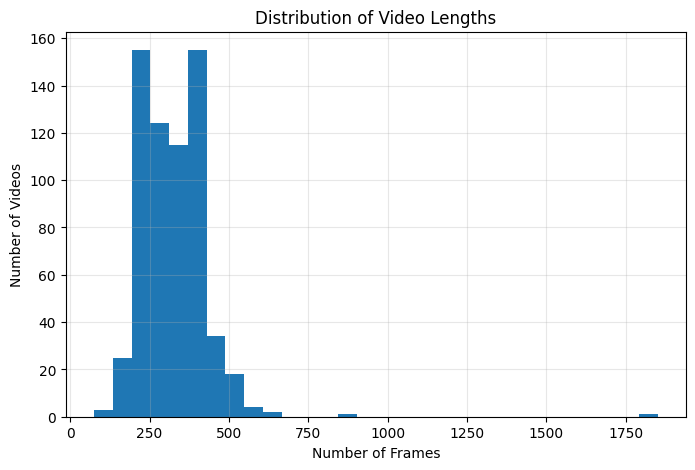

In [13]:
# =====================================
# Distribution of Video Lengths
# =====================================

plt.figure(figsize=(8, 5))

plt.hist(df["num_frames"], bins=30)

plt.title("Distribution of Video Lengths")
plt.xlabel("Number of Frames")
plt.ylabel("Number of Videos")

plt.grid(alpha=0.3)

plt.show()

In [14]:
# =====================================
# Dataset Overview
# =====================================

print(f"Dataset Shape: {df.shape}")

print("\nClass Distribution:")
print(df["class_name"].value_counts())

print("\nClass Percentage:")
print((df["class_name"].value_counts(normalize=True) * 100).round(2))

Dataset Shape: (637, 5)

Class Distribution:
class_name
shop lifters        324
non shop lifters    313
Name: count, dtype: int64

Class Percentage:
class_name
shop lifters        50.86
non shop lifters    49.14
Name: proportion, dtype: float64


In [15]:

# =====================================
# Configuration
# =====================================

SEED = 42

# Dataset
IMAGE_SIZE = 112
NUM_FRAMES = 128
NUM_CLASSES = 2
TEST_SIZE = 0.20

# R3D-18 pretrained on Kinetics expects RGB videos normalized with these stats.
VIDEO_MEAN = np.array([0.43216, 0.394666, 0.37645], dtype=np.float32).reshape(3, 1, 1, 1)
VIDEO_STD = np.array([0.22803, 0.22145, 0.216989], dtype=np.float32).reshape(3, 1, 1, 1)

# Model
USE_PRETRAINED_WEIGHTS = True
FREEZE_BACKBONE = False

# DataLoader
BATCH_SIZE = 2
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

# Training
EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

# Scheduler
LR_FACTOR = 0.5
LR_PATIENCE = 3


In [16]:

# =====================================
# Train / Test Split
# =====================================

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"]
)

# Reset indices
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train Set : {len(train_df)}")
print(f"Test Set  : {len(test_df)}")

print("\nTrain Distribution")
print(train_df["class_name"].value_counts(normalize=True).round(3))

print("\nTest Distribution")
print(test_df["class_name"].value_counts(normalize=True).round(3))


Train Set : 509
Test Set  : 128

Train Distribution
class_name
shop lifters        0.509
non shop lifters    0.491
Name: proportion, dtype: float64

Test Distribution
class_name
shop lifters        0.508
non shop lifters    0.492
Name: proportion, dtype: float64


In [17]:
def load_video(
    video_path,
    num_frames=NUM_FRAMES,
    img_size=IMAGE_SIZE
):
    # =====================================
    # Load and Sample Video Frames
    # =====================================

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Return empty frames if the video is corrupted or empty
    if total_frames <= 0:
        cap.release()
        return np.zeros(
            (num_frames, img_size, img_size, 3),
            dtype=np.float32
        )

    # Uniformly sample frames across the entire video
    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=np.int32
    )

    required_frames = set(frame_indices.tolist())
    collected_frames = {}

    current_idx = 0

    # Read frames sequentially for reliable frame extraction
    while True:

        success, frame = cap.read()

        if not success:
            break

        if current_idx in required_frames:

            if frame is None:
                current_idx += 1
                continue

            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Resize frame
            frame = cv2.resize(frame, (img_size, img_size))

            # Normalize pixel values to [0, 1]
            frame = frame.astype(np.float32) / 255.0

            collected_frames[current_idx] = frame

        current_idx += 1

    cap.release()

    sampled_frames = []
    last_valid_frame = None

    # Fill missing frames using the last valid frame
    for idx in frame_indices:

        if idx in collected_frames:

            last_valid_frame = collected_frames[idx]
            sampled_frames.append(last_valid_frame)

        elif last_valid_frame is not None:

            sampled_frames.append(last_valid_frame)

        else:

            sampled_frames.append(
                np.zeros(
                    (img_size, img_size, 3),
                    dtype=np.float32
                )
            )

    sampled_frames = np.stack(sampled_frames).astype(np.float32)

    return sampled_frames

In [18]:
def augment_video(frames, img_size=IMAGE_SIZE):
    return frames

In [19]:

class VideoDataset(Dataset):

    def __init__(
        self,
        dataframe,
        num_frames=NUM_FRAMES,
        img_size=IMAGE_SIZE,
        train=True
    ):
        # =====================================
        # Initialize Dataset
        # =====================================

        self.dataframe = dataframe.reset_index(drop=True)
        self.num_frames = num_frames
        self.img_size = img_size
        self.train = train

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        # Load video path and label
        video_path = self.dataframe.iloc[idx]["video_path"]
        label = self.dataframe.iloc[idx]["label"]

        # Load sampled video frames
        frames = load_video(
            video_path,
            self.num_frames,
            self.img_size
        )

        # Apply data augmentation during training only
        if self.train:
            frames = augment_video(
                frames,
                self.img_size
            )

        # Convert from (T, H, W, C) to (C, T, H, W)
        frames = np.transpose(frames, (3, 0, 1, 2))

        # Normalize for the pretrained R3D-18 backbone
        frames = (frames - VIDEO_MEAN) / VIDEO_STD

        # Convert to PyTorch tensors
        frames = torch.from_numpy(frames).float()
        label = torch.tensor(label, dtype=torch.long)

        return frames, label


In [20]:

# =====================================
# Create Datasets
# =====================================

train_dataset = VideoDataset(
    train_df,
    num_frames=NUM_FRAMES,
    img_size=IMAGE_SIZE,
    train=True
)

test_dataset = VideoDataset(
    test_df,
    num_frames=NUM_FRAMES,
    img_size=IMAGE_SIZE,
    train=False
)


In [21]:
from torch.utils.data import WeightedRandomSampler

class_counts = train_df["label"].value_counts().sort_index()

sample_weights = train_df["label"].map(
    lambda lbl: 1.0 / class_counts[lbl]
).values

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [22]:

# =====================================
# Create DataLoaders
# =====================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=False
)


In [23]:
# =====================================
# Check DataLoader Output
# =====================================

videos, labels = next(iter(train_loader))

print(f"Videos Shape : {videos.shape}")
print(f"Labels Shape : {labels.shape}")
print(f"Labels       : {labels}")
print(f"Data Type    : {videos.dtype}")

Videos Shape : torch.Size([2, 3, 128, 112, 112])
Labels Shape : torch.Size([2])
Labels       : tensor([0, 0])
Data Type    : torch.float32


In [24]:

def build_r3d18_model(
    num_classes=NUM_CLASSES,
    pretrained=USE_PRETRAINED_WEIGHTS,
    freeze_backbone=FREEZE_BACKBONE
):
    # =====================================
    # Pretrained R3D-18 Model
    # =====================================

    weights = R3D_18_Weights.DEFAULT if pretrained else None
    model = r3d_18(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )

    return model


In [25]:

# =====================================
# Initialize Model
# =====================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_r3d18_model(num_classes=NUM_CLASSES).to(device)

# Test model with a dummy input
# Input shape for torchvision video models: (B, C, T, H, W)
dummy_input = torch.randn(
    BATCH_SIZE,
    3,
    NUM_FRAMES,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)

output = model(dummy_input)

print(f"Model: pretrained R3D-18")
print(f"Output Shape : {output.shape}")


Model: pretrained R3D-18
Output Shape : torch.Size([2, 2])


In [26]:
# =====================================
# Loss Function, Optimizer and Scheduler
# =====================================

import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("Class Weights:", class_weights.cpu().numpy())

# Loss Function
criterion = nn.CrossEntropyLoss(weight=class_weights)


# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE
)


Class Weights: [1.018     0.9826255]


In [27]:

# =====================================
# Training History
# =====================================

train_losses = []
train_accs = []


In [28]:

# =====================================
# Training Loop
# Train only; keep test set for final evaluation.
# =====================================

best_train_loss = float("inf")

for epoch in range(EPOCHS):

    ##########################
    # Training
    ##########################

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for videos, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}"):

        videos = videos.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(videos)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f}"
    )

    ##########################
    # Save Best Training Loss Model
    ##########################

    if train_loss < best_train_loss:
        best_train_loss = train_loss

        torch.save(
            model.state_dict(),
            "best_r3d18_train_loss_model.pth"
        )

        print("Saved Best Training-Loss Model")

    ##########################
    # Scheduler
    ##########################

    scheduler.step(train_loss)

    ##########################
    # History
    ##########################

    train_losses.append(train_loss)
    train_accs.append(train_accuracy)


Epoch 1/10:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch 1/10
Train Loss: 0.3821 | Train Acc: 0.8248
Saved Best Training-Loss Model


Epoch 2/10:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch 2/10
Train Loss: 0.0612 | Train Acc: 0.9882
Saved Best Training-Loss Model


Epoch 3/10:   0%|          | 0/254 [00:00<?, ?it/s]

...

Epoch 8/10
Train Loss: 0.0013 | Train Acc: 1.0000
Saved Best Training-Loss Model


Epoch 9/10:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch 9/10
Train Loss: 0.0011 | Train Acc: 1.0000
Saved Best Training-Loss Model


Epoch 10/10:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch 10/10
Train Loss: 0.0008 | Train Acc: 1.0000
Saved Best Training-Loss Model


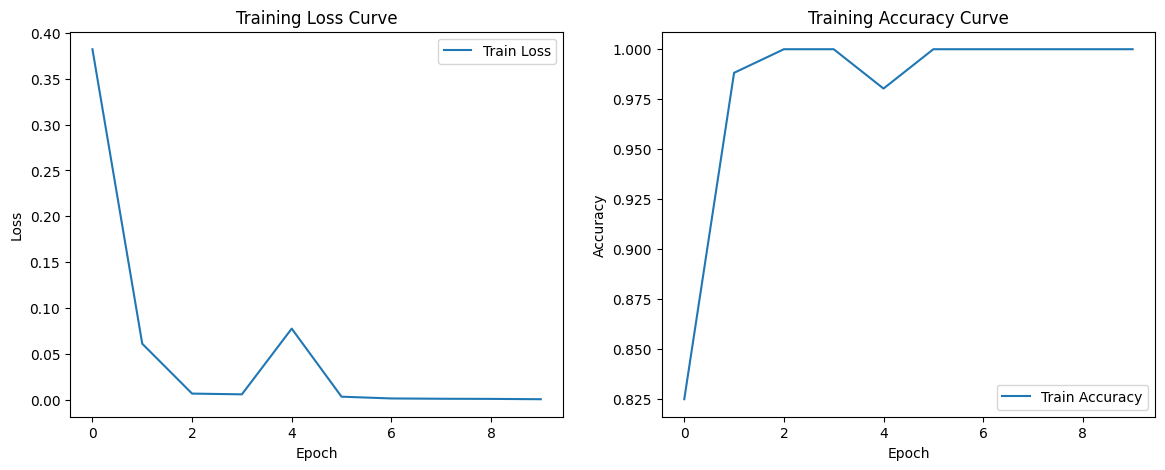

In [29]:

# =====================================
# Plot Training History
# =====================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# =====================================
# Loss Curve
# =====================================

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

# =====================================
# Accuracy Curve
# =====================================

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")
plt.legend()

plt.show()


Test Accuracy : 0.9922
Precision     : 0.9848
Recall        : 1.0000
F1-score      : 0.9924

Classification Report:

                 precision    recall  f1-score   support

Non-Shoplifting       1.00      0.98      0.99        63
    Shoplifting       0.98      1.00      0.99        65

       accuracy                           0.99       128
      macro avg       0.99      0.99      0.99       128
   weighted avg       0.99      0.99      0.99       128



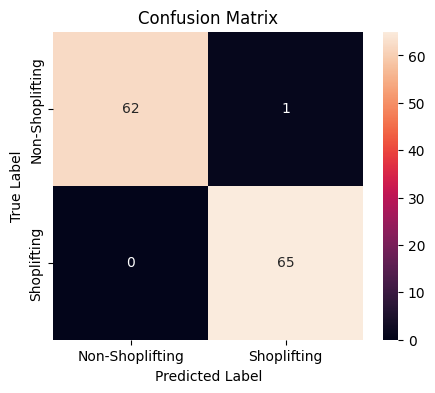

In [30]:
# =====================================
# Final Model Evaluation on Test Set
# Calculate Accuracy, Precision, Recall, F1-score
# and analyze class imbalance effect
# =====================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


# Set model to evaluation mode
model.eval()


# Lists to store predictions and true labels
all_labels = []
all_preds = []


# Disable gradient calculation during evaluation
with torch.no_grad():

    # Iterate through test batches
    for videos, labels in test_loader:

        # Move data to GPU/CPU device
        videos = videos.to(device)
        labels = labels.to(device)


        # Forward pass
        outputs = model(videos)


        # Get predicted class
        _, predicted = torch.max(outputs, 1)


        # Store predictions and labels
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())



# =====================================
# Calculate Evaluation Metrics
# =====================================

test_accuracy = accuracy_score(
    all_labels,
    all_preds
)


test_precision = precision_score(
    all_labels,
    all_preds,
    zero_division=0
)


test_recall = recall_score(
    all_labels,
    all_preds,
    zero_division=0
)


test_f1 = f1_score(
    all_labels,
    all_preds,
    zero_division=0
)



# Print main metrics
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Precision     : {test_precision:.4f}")
print(f"Recall        : {test_recall:.4f}")
print(f"F1-score      : {test_f1:.4f}")



# =====================================
# Detailed Classification Report
# Shows performance for each class
# =====================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Non-Shoplifting",
            "Shoplifting"
        ],
        zero_division=0
    )
)



# =====================================
# Confusion Matrix
# Analyze model bias between classes
# =====================================

cm = confusion_matrix(
    all_labels,
    all_preds
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Non-Shoplifting",
        "Shoplifting"
    ],
    yticklabels=[
        "Non-Shoplifting",
        "Shoplifting"
    ]
)


plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()
